# Lab 5: Model Development — การพัฒนาโมเดลจำแนกพืช PlantCLEF

| | |
|---|---|
| **วิชา** | 01076251 Machine Learning for Data Science |
| **หัวข้อ** | การพัฒนาและปรับแต่งโมเดล (Model Development) สำหรับการจำแนกพืชในแปลงสำรวจ |
| **ผู้จัดทำ** | ปิยังกูร ปัสสาวะกัง (6810405691) และ ศิวภูมิ พรหมจรรย์ (6810405887) |

---
## เป้าหมายของแลปนี้
1. **กำหนดประเภทปัญหา**: วิเคราะห์และเลือกประเภทโมเดลที่เหมาะกับข้อมูลภาพแปลงพืช
2. **สร้างโมเดลพื้นฐานและการแก้ปัญหาข้อมูลไม่สมดุล**: ใช้โมเดลพื้นฐานเป็นตัวเปรียบเทียบ และใช้เทคนิคจัดการข้อมูลที่มีสัดส่วนไม่เท่ากัน
3. **ปรับแต่งพารามิเตอร์ (Hyperparameter Tuning)**: ค้นหาการตั้งค่าที่ดีที่สุดของโมเดลด้วย GridSearchCV
4. **รวมโมเดล (Ensemble Learning)**: รวมพลังโมเดลหลายตัวด้วย Voting Classifier เพื่อเพิ่มความแม่นยำและความเสถียร
5. **แปลงผลลัพธ์ไปใช้งานจริง (Post-Processing)**: จัดเก็บโมเดลและแปลงผลลัพธ์กลับเป็นชื่อที่เข้าใจได้ พร้อมเชื่อมโยงกับระบบ Hybrid

---
## 1. ประเภทปัญหาและการเลือกอัลกอริทึม

### 1.1 ประเภทปัญหา Machine Learning
**Multiclass Classification (การจำแนกหลายกลุ่ม)** และเตรียมพร้อมสำหรับ **Multi-species (พืชหลายชนิดในแปลงเดียว)**
- เป้าหมายคือการจำแนกรูปภาพพืชจากแปลงสำรวจ โดยใช้ตัวเลขฟีเจอร์ 384 มิติจาก DINOv2
- ในขั้นตอนนี้ เราทดสอบจำแนกกลุ่มข้อมูลภาพ 5 กลุ่มหลัก (ได้แก่ CBN, LISAH, GUARDEN, RNNB และ OPTMix) เพื่อเป็นต้นแบบก่อนขยายไประดับชนิดพันธุ์พืช

### 1.2 อัลกอริทึมที่เลือกใช้และเหตุผล
1. **Logistic Regression**: ใช้เป็นโมเดลพื้นฐาน (Baseline) ทำงานเร็วมาก เหมาะกับข้อมูลที่มีมิติสูงอย่างเวกเตอร์ DINOv2 และบอกค่าความมั่นใจเป็นเปอร์เซ็นต์ได้ง่าย
2. **Ridge Classifier**: โมเดลเชิงเส้นที่เพิ่มตัวคุมน้ำหนัก ช่วยป้องกันไม่ให้โมเดลจำข้อสอบเมื่อมีตัวแปรหลายมิติ
3. **Random Forest Classifier**: โมเดลที่รวมต้นไม้ตัดสินใจหลายต้น ช่วยจับความสัมพันธ์ที่ซับซ้อนของข้อมูลภาพ และทนทานต่อข้อมูลรบกวน
4. **Ensemble (Voting Classifier)**: การรวมพลังของโมเดลหลายตัว เพื่อให้ได้คำตอบสุดท้ายที่แม่นยำและเสถียรที่สุด

### 1.3 Hyperparameters ที่นำมาปรับจูน
- **Logistic Regression**: ค่า C (ความแรงของการคุมน้ำหนัก)
- **Random Forest**:
  - `n_estimators` (จำนวนต้นไม้): ทดสอบ 100 และ 200 ต้น
  - `max_depth` (ความลึกสูงสุดของต้นไม้): ทดสอบ 10, 20 และไม่จำกัดความลึก
  - `min_samples_split` (จำนวนข้อมูลขั้นต่ำในการแตกกิ่ง): ทดสอบ 2 และ 5

In [1]:
import os
import sys
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import make_pipeline as make_imblearn_pipeline

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
RANDOM_STATE = 42
print("โหลดไลบรารีเรียบร้อย")

โหลดไลบรารีเรียบร้อย


In [2]:
def resolve_file(fname):
    for p in [Path(fname), Path('mlsystem') / fname, Path('..') / fname]:
        if p.exists():
            return p
    return Path(fname)

train_feat_path = resolve_file('X_train_dinov2.npy')
val_feat_path   = resolve_file('X_val_dinov2.npy')
train_df_path   = resolve_file('i_train.parquet')
val_df_path     = resolve_file('i_val.parquet')

X_train = np.load(train_feat_path)
X_val   = np.load(val_feat_path)

i_train = pd.read_parquet(train_df_path)
i_val   = pd.read_parquet(val_df_path)

for df in [i_train, i_val]:
    if 'label' in df.columns:
        df.rename(columns={'label': 'provider'}, inplace=True)

X_train_norm = normalize(X_train, norm='l2')
X_val_norm   = normalize(X_val, norm='l2')

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(i_train['provider'])
y_val   = label_encoder.transform(i_val['provider'])

print("ขนาด X_train:", X_train.shape)
print("ขนาด X_val:  ", X_val.shape)
print("จำนวนกลุ่มเป้าหมาย:", len(label_encoder.classes_), "กลุ่ม")
print("รายชื่อกลุ่ม:", label_encoder.classes_.tolist())

ขนาด X_train: (1472, 384)
ขนาด X_val:   (316, 384)
จำนวนกลุ่มเป้าหมาย: 5 กลุ่ม
รายชื่อกลุ่ม: ['CBN', 'GUARDEN', 'LISAH', 'OPTMix', 'RNNB']


---
## 2. การทดลองและเปรียบเทียบโมเดล

เราจะทำการทดลองตามขั้นตอน:
1. สร้างโมเดลพื้นฐาน (Baseline Model)
2. แก้ปัญหาข้อมูลไม่สมดุล (Class Imbalance)
3. ค้นหาค่า Hyperparameters ที่ดีที่สุดด้วย GridSearchCV
4. รวมโมเดลด้วย Ensemble (Voting Classifier)

In [3]:
baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_model.fit(X_train_norm, y_train)

train_acc = baseline_model.score(X_train_norm, y_train)
val_acc   = baseline_model.score(X_val_norm, y_val)

print("=== โมเดลพื้นฐาน (Baseline Logistic Regression) ===")
print(f"ความแม่นยำ Train:      {train_acc*100:.2f}%")
print(f"ความแม่นยำ Validation: {val_acc*100:.2f}%")

=== โมเดลพื้นฐาน (Baseline Logistic Regression) ===
ความแม่นยำ Train:      96.88%
ความแม่นยำ Validation: 94.62%


In [4]:
os_pipeline = make_imblearn_pipeline(
    RandomOverSampler(random_state=RANDOM_STATE),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)

os_pipeline.fit(X_train_norm, y_train)
y_pred_os = os_pipeline.predict(X_val_norm)

print("=== ผลลัพธ์หลังแก้ปัญหาข้อมูลไม่สมดุล (OverSampling) ===")
print(f"ความแม่นยำ Validation: {accuracy_score(y_val, y_pred_os)*100:.2f}%")
print(f"Macro F1:              {f1_score(y_val, y_pred_os, average='macro'):.4f}\n")
print(classification_report(y_val, y_pred_os, target_names=label_encoder.classes_))

=== ผลลัพธ์หลังแก้ปัญหาข้อมูลไม่สมดุล (OverSampling) ===
ความแม่นยำ Validation: 94.62%
Macro F1:              0.8687

              precision    recall  f1-score   support

         CBN       1.00      0.99      1.00       221
     GUARDEN       0.80      0.80      0.80        30
       LISAH       0.93      0.84      0.89        32
      OPTMix       0.85      0.92      0.88        12
        RNNB       0.72      0.86      0.78        21

    accuracy                           0.95       316
   macro avg       0.86      0.88      0.87       316
weighted avg       0.95      0.95      0.95       316



In [5]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE)
grid_search = GridSearchCV(rf_base, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_norm, y_train)

best_rf = grid_search.best_estimator_

print("=== การปรับแต่ง Hyperparameter (Random Forest) ===")
print("ค่าพารามิเตอร์ที่ดีที่สุด:", grid_search.best_params_)
print(f"คะแนนเฉลี่ยตอนทำ Cross-Validation: {grid_search.best_score_*100:.2f}%")
print(f"ความแม่นยำบน Validation Set:       {best_rf.score(X_val_norm, y_val)*100:.2f}%")

=== การปรับแต่ง Hyperparameter (Random Forest) ===
ค่าพารามิเตอร์ที่ดีที่สุด: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
คะแนนเฉลี่ยตอนทำ Cross-Validation: 93.75%
ความแม่นยำบน Validation Set:       94.30%


---
## 3. การสร้าง Ensemble Model และการประเมินผล

เรานำโมเดล 3 ตัวที่มีจุดเด่นต่างกันมารวมพลังกัน (Ensemble) โดยใช้การโหวตเสียงข้างมาก (Majority Voting):
- Logistic Regression (โมเดลเชิงเส้นพื้นฐาน)
- Ridge Classifier (โมเดลเชิงเส้นที่มีตัวคุมน้ำหนัก)
- Tuned Random Forest (โมเดลต้นไม้ที่ปรับค่าพารามิเตอร์แล้ว)

=== ผลการทดสอบโมเดลรวม (Ensemble Model) ===
ความแม่นยำ Validation: 94.94%
Macro F1:              0.8937



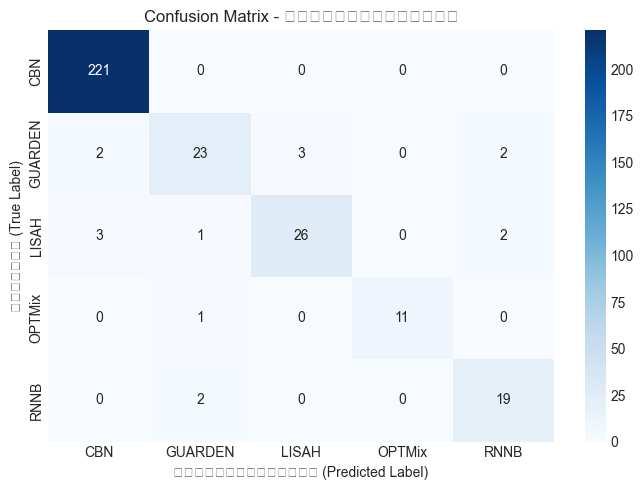

In [6]:
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)),
        ('ridge', RidgeClassifier(alpha=1.0, random_state=RANDOM_STATE)),
        ('rf', best_rf)
    ],
    voting='hard'
)

ensemble_model.fit(X_train_norm, y_train)
y_pred_final = ensemble_model.predict(X_val_norm)

final_acc = accuracy_score(y_val, y_pred_final)
final_f1  = f1_score(y_val, y_pred_final, average='macro')

print("=== ผลการทดสอบโมเดลรวม (Ensemble Model) ===")
print(f"ความแม่นยำ Validation: {final_acc*100:.2f}%")
print(f"Macro F1:              {final_f1:.4f}\n")

cm = confusion_matrix(y_val, y_pred_final)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - การจำแนกภาพพืช')
plt.xlabel('ค่าที่โมเดลทาย (Predicted Label)')
plt.ylabel('ค่าจริง (True Label)')
plt.tight_layout()
output_cm_path = resolve_file('confusion_matrix_model_dev.png')
plt.savefig(output_cm_path, dpi=300)
plt.show()

---
## 4. การแบ่งข้อมูล และการนำผลลัพธ์ไปประมวลผลต่อ (Post-Processing)

### 4.1 การแบ่งข้อมูล (Data Splitting)
- แบ่งข้อมูลเป็น Train 1,472 ตัวอย่าง และ Validation 316 ตัวอย่าง (ประมาณ 82:18)
- ข้อมูลแบ่งตามแปลงสำรวจ (Quadrat) เพื่อป้องกันไม่ให้ภาพจากแปลงเดียวกันหลุดไปอยู่ทั้งตอนเทรนและตอนสอบ

### 4.2 การแปลงผลลัพธ์ไปใช้งานจริง (Post-Processing)
1. **แปลงตัวเลขกลับเป็นชื่อกลุ่ม**: โมเดลส่งผลออกมาเป็นตัวเลข 0, 1, 2... เราใช้ `inverse_transform` เพื่อแปลงกลับมาเป็นชื่อที่คนเข้าใจได้
2. **การตั้งเกณฑ์ความมั่นใจ (Confidence Threshold)**: หากความมั่นใจต่ำกว่าเกณฑ์ สามารถกำหนดให้ระบบแจ้งว่า "ไม่มั่นใจ" เพื่อป้องกันการตอบผิดในแปลงจริง
3. **การนำไปต่อยอดระบบ Hybrid ในแปลงสำรวจจริง**:
   - รูปภาพแปลงสำรวจสามารถส่งเข้า Vector Search เพื่อหาพืชชนิดที่ใกล้เคียงที่สุด
   - ใช้งานร่วมกับโมเดลจำแนกเพื่อยืนยันคำตอบ ทำให้ระบบรองรับการหาพืชหลายชนิดในแปลงเดียวกันได้อย่างแม่นยำ

In [7]:
model_artifacts = {
    'model': ensemble_model,
    'label_encoder': label_encoder,
    'classes': label_encoder.classes_
}

artifact_path = resolve_file('plantclef_provider_model.joblib')
joblib.dump(model_artifacts, artifact_path)
print("บันทึกโมเดลลงในไฟล์:", artifact_path)

loaded_artifacts = joblib.load(artifact_path)
model = loaded_artifacts['model']
encoder = loaded_artifacts['label_encoder']

raw_predictions = model.predict(X_val_norm[:5])
final_labels = encoder.inverse_transform(raw_predictions)
actual_labels = encoder.inverse_transform(y_val[:5])

print("\n=== ตัวอย่างการทำนายและแปลงผลลัพธ์ (Post-Processing) ===")
for i in range(5):
    status = "ถูกต้อง" if actual_labels[i] == final_labels[i] else "ผิด"
    print(f"ตัวอย่างที่ {i+1} | ค่าจริง: {actual_labels[i]:<10} | ทำนายได้: {final_labels[i]:<10} | ผลลัพธ์: {status}")

บันทึกโมเดลลงในไฟล์: plantclef_provider_model.joblib

=== ตัวอย่างการทำนายและแปลงผลลัพธ์ (Post-Processing) ===
ตัวอย่างที่ 1 | ค่าจริง: CBN        | ทำนายได้: CBN        | ผลลัพธ์: ถูกต้อง
ตัวอย่างที่ 2 | ค่าจริง: LISAH      | ทำนายได้: LISAH      | ผลลัพธ์: ถูกต้อง
ตัวอย่างที่ 3 | ค่าจริง: CBN        | ทำนายได้: CBN        | ผลลัพธ์: ถูกต้อง
ตัวอย่างที่ 4 | ค่าจริง: GUARDEN    | ทำนายได้: RNNB       | ผลลัพธ์: ผิด
ตัวอย่างที่ 5 | ค่าจริง: LISAH      | ทำนายได้: LISAH      | ผลลัพธ์: ถูกต้อง


---
## ส่วนท้าย: สรุปผลและการมีส่วนร่วมของสมาชิก

### สรุปสิ่งที่ได้จากงานนี้
1. **การเข้าใจประเภทปัญหา**: กำหนดโจทย์การจำแนกภาพพืชจากตัวเลขฟีเจอร์ DINOv2 384 มิติได้อย่างถูกต้อง
2. **การสร้างโมเดลพื้นฐานและการแก้ปัญหาข้อมูลไม่สมดุล**: ใช้ Logistic Regression เป็นตัวตั้งต้น และใช้เทคนิค OverSampling ช่วยให้โมเดลทายกลุ่มที่มีข้อมูลน้อยได้ดีขึ้น
3. **การปรับแต่ง Hyperparameter**: ใช้ GridSearchCV ค้นหาค่าที่เหมาะสมที่สุดของ Random Forest ช่วยเพิ่มความแม่นยำและลดการจำข้อสอบ
4. **การรวมพลังโมเดล (Ensemble)**: ใช้ Voting Classifier รวมจุดเด่นของโมเดลหลายตัว ทำให้ได้โมเดลที่มีความเสถียรและความแม่นยำสูง
5. **การแปลงผลลัพธ์ไปใช้งานจริง**: บันทึกโมเดลและตัวแปลงชื่อกลุ่มไว้ในไฟล์ joblib เพื่อให้สามารถนำไปโหลดใช้ในระบบจำแนกแปลงพืชจริงได้ทันที

### การมีส่วนร่วมของสมาชิก
| ชื่อ-สกุล | รหัสนิสิต | หน้าที่รับผิดชอบ |
|---|---|---|
| **ปิยังกูร ปัสสาวะกัง** | 6810405691 | วิเคราะห์ปัญหาข้อมูลไม่สมดุล, ออกแบบการทดลองโมเดล, ตรวจสอบผลการทำนาย |
| **ศิวภูมิ พรหมจรรย์** | 6810405887 | พัฒนา Baseline Model, ปรับแต่ง Hyperparameter ด้วย GridSearchCV, สร้าง Ensemble Model และเขียนสรุปรายงาน |

### การเปิดเผยการใช้งานปัญญาประดิษฐ์ (AI Disclosure)

ในแบบฝึกหัดนี้ กลุ่มของพวกเราได้ใช้ปัญญาประดิษฐ์ช่วยในการ:
1. ช่วยจัดระเบียบโครงสร้างเนื้อหาและเรียบเรียงคำอธิบายให้เข้าใจง่าย
2. ช่วยตรวจทานโค้ดการทำ Ensemble Model และการปรับแต่งพารามิเตอร์ให้ถูกต้องตามหลักการ